In [1]:
# ============================================================
# Q5 — MCAR vs MAR vs MNAR Simulation
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Load complete dataset
# ------------------------------------------------------------

data = load_diabetes(as_frame=True)

X_complete = data.data.copy()

print("Dataset shape:", X_complete.shape)

print(
    "\nTotal original missing values:",
    X_complete.isnull().sum().sum()
)


# ============================================================
# MCAR
# ============================================================

rng = np.random.RandomState(42)

X_mcar = X_complete.copy()

mcar_rate = 0.20

mcar_mask = (
    rng.rand(len(X_mcar))
    <
    mcar_rate
)

X_mcar.loc[
    mcar_mask,
    "bmi"
] = np.nan


print("\nMCAR missing rate:")

print(
    X_mcar["bmi"].isnull().mean()
)


# ============================================================
# MAR
# ============================================================

X_mar = X_complete.copy()

# Missingness depends on observed variable AGE

age = X_complete["age"]

# Convert age into a probability

prob_mar = 1 / (
    1 +
    np.exp(
        -(age - age.mean()) * 5
    )
)

mar_mask = (
    rng.rand(len(X_mar))
    <
    prob_mar
)

X_mar.loc[
    mar_mask,
    "bmi"
] = np.nan


print("\nMAR missing rate:")

print(
    X_mar["bmi"].isnull().mean()
)


# ============================================================
# MNAR
# ============================================================

X_mnar = X_complete.copy()

# Missingness depends on BMI itself.
# We use the ORIGINAL complete BMI values
# to generate the missingness mechanism.

bmi = X_complete["bmi"]

prob_mnar = 1 / (
    1 +
    np.exp(
        -(bmi - bmi.mean()) * 8
    )
)

mnar_mask = (
    rng.rand(len(X_mnar))
    <
    prob_mnar
)

X_mnar.loc[
    mnar_mask,
    "bmi"
] = np.nan


print("\nMNAR missing rate:")

print(
    X_mnar["bmi"].isnull().mean()
)

Dataset shape: (442, 10)

Total original missing values: 0

MCAR missing rate:
0.23076923076923078

MAR missing rate:
0.5226244343891403

MNAR missing rate:
0.47737556561085975


In [2]:
# ============================================================
# 2. Create missingness indicators
# ============================================================

mcar_indicator = (
    X_mcar["bmi"]
    .isnull()
    .astype(int)
)

mar_indicator = (
    X_mar["bmi"]
    .isnull()
    .astype(int)
)

mnar_indicator = (
    X_mnar["bmi"]
    .isnull()
    .astype(int)
)

In [3]:
# ============================================================
# 3. Function to test predictability of missingness
# ============================================================

def missingness_auc(df, target_column, predictor_columns):
    
    # Missingness indicator
    missing_indicator = (
        df[target_column]
        .isnull()
        .astype(int)
    )
    
    # Use observed variables
    X_predictors = df[predictor_columns].copy()
    
    # Simple median filling only for this diagnostic model
    X_predictors = X_predictors.fillna(
        X_predictors.median()
    )
    
    # Logistic Regression
    model = LogisticRegression(
        max_iter=2000
    )
    
    model.fit(
        X_predictors,
        missing_indicator
    )
    
    probability = model.predict_proba(
        X_predictors
    )[:, 1]
    
    auc = roc_auc_score(
        missing_indicator,
        probability
    )
    
    return auc

In [4]:
# ============================================================
# 4. Predictor variables
# ============================================================

predictor_columns = [
    "age",
    "bp",
    "s1",
    "s2",
    "s3",
    "s4",
    "s5",
    "s6"
]

In [5]:
# ============================================================
# 5. MCAR diagnostic
# ============================================================

auc_mcar = missingness_auc(
    X_mcar,
    "bmi",
    predictor_columns
)

print(
    "MCAR missingness prediction AUC:",
    auc_mcar
)

MCAR missingness prediction AUC: 0.5370818915801615


In [6]:
# ============================================================
# 6. MAR diagnostic
# ============================================================

auc_mar = missingness_auc(
    X_mar,
    "bmi",
    predictor_columns
)

print(
    "MAR missingness prediction AUC:",
    auc_mar
)

MAR missingness prediction AUC: 0.6000082066432777


In [7]:
# ============================================================
# 7. MNAR diagnostic
# ============================================================

auc_mnar = missingness_auc(
    X_mnar,
    "bmi",
    predictor_columns
)

print(
    "MNAR missingness prediction AUC:",
    auc_mnar
)

MNAR missingness prediction AUC: 0.5868365441825159


In [8]:
# ============================================================
# 8. Comparison table
# ============================================================

q5_results = pd.DataFrame({
    
    "Missingness Mechanism": [
        "MCAR",
        "MAR",
        "MNAR"
    ],
    
    "Missingness Prediction AUC": [
        auc_mcar,
        auc_mar,
        auc_mnar
    ]
})

display(q5_results)

,Missingness Mechanism,Missingness Prediction AUC
0,MCAR,0.537082
1,MAR,0.600008
2,MNAR,0.586837


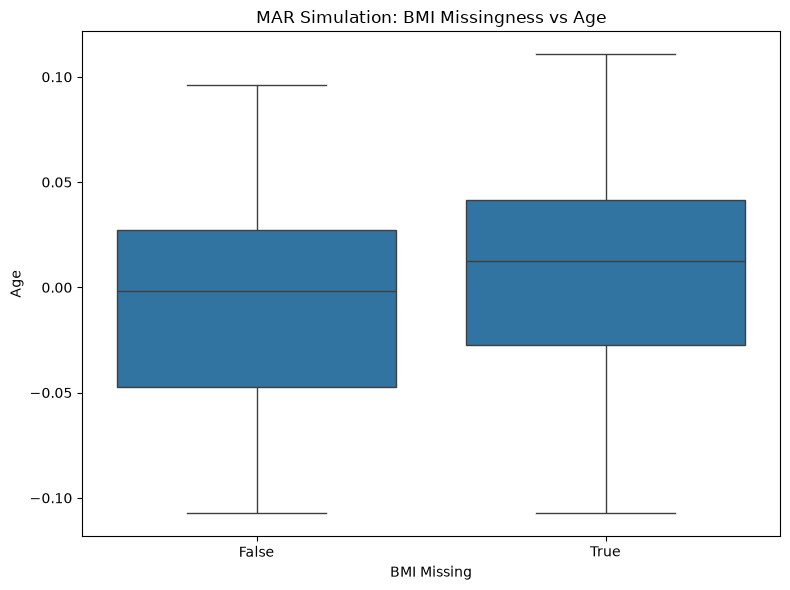

In [9]:
# ============================================================
# 9. Visualize MAR
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    x=X_mar["bmi"].isnull(),
    y=X_mar["age"]
)

plt.xlabel("BMI Missing")
plt.ylabel("Age")
plt.title("MAR Simulation: BMI Missingness vs Age")

plt.tight_layout()
plt.show()

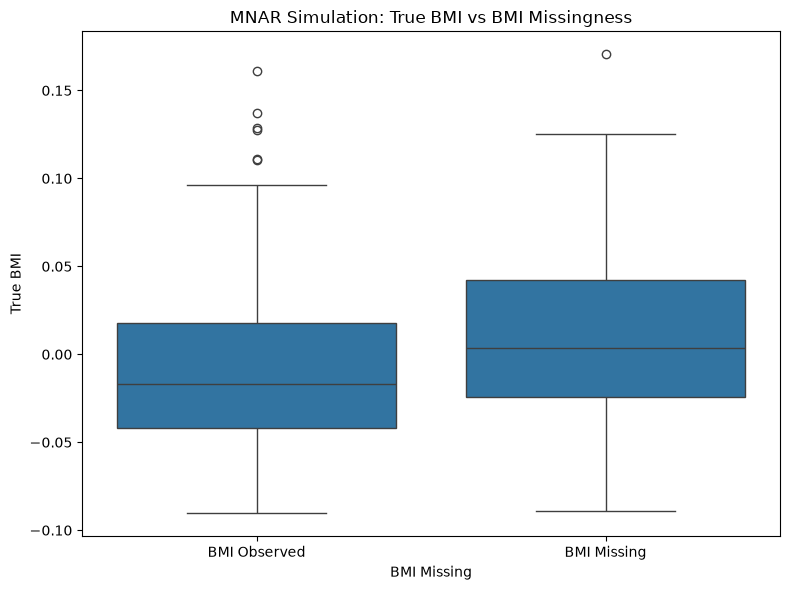

In [10]:
# ============================================================
# 10. Visualize MNAR using known ground truth
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    x=mnar_indicator,
    y=X_complete["bmi"]
)

plt.xlabel("BMI Missing")
plt.ylabel("True BMI")
plt.title(
    "MNAR Simulation: True BMI vs BMI Missingness"
)

plt.xticks(
    [0, 1],
    ["BMI Observed", "BMI Missing"]
)

plt.tight_layout()
plt.show()